# Blinkit Sales Analysis
### A Comprehensive Data Science Project on Blinkit Sales Analysis
## Project Overview
The Blinkit Sales dataset contains information about grocery products sold across different Blinkit outlets. It includes details such as item type, item weight, fat content, visibility, maximum retail price (MRP), outlet characteristics, and sales. The dataset consists of 8,523 records and 12 features, making it suitable for data analysis and visualization. The primary objective of this dataset is to analyze the factors affecting product sales and identify meaningful business insights.
### Research Questions
1. How have blinkit sales evolved over the 32-year period from 1985 to 2009?
2. How do different product categories influence item outlet sales?
3. How does the type of outlet affect the sales performance of products?
4. What is the relationship between an item's Maximum Retail Price (MRP) and its sales?
5. How does the location of an outlet impact overall sales performance?
6. Which factors have the greatest influence on item outlet sales?
### Dataset overview

**source** Source: Kaggle (https://www.kaggle.com/datasets/mukeshgadri/blinkit-dataset) – Blinkit Sales Dataset

Coverage:

📅 Period: Outlet establishment years 1985–2009 (24 years)
🏪 Outlets: 10 different Blinkit outlet stores
🛒 Products: 8,523 grocery product records across multiple product categories
📍 Coverage: Outlet size, outlet type, location type, item type, fat content, item visibility, MRP, and sales metrics

### important Considerations

**Dataset Reliability:**
The dataset was obtained from Kaggle and is intended for educational and analytical purposes. While it provides valuable insights into grocery sales, it may not represent the complete operational data of Blinkit.

**Data Limitations:**
The dataset contains missing values in some attributes (such as Item Weight and Outlet Size) and represents sales from a limited number of outlets. Therefore, the findings should be interpreted within these constraints.

**Scope of Analysis:**
This analysis focuses on identifying sales patterns and the factors influencing product sales using exploratory data analysis (EDA) and visualization techniques. The results are intended for learning and business insight generation rather than making real-world business decisions.

In [8]:
# Importing required libraries
import pandas as dp
import numpy as np
import matplotlib.pyplot as mlt
import seaborn as sb
import plotly.express as pt
import plotly.io as pio

## LOADING THE DATA-SET

In [9]:
ds=dp.read_csv("mani.csv")
ds.head(50)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
5,FDP36,10.395,Regular,0.000000,Baking Goods,51.4008,OUT018,2009,Medium,Tier 3,Supermarket Type2,556.6088
6,FDO10,13.650,Regular,0.012741,Snack Foods,57.6588,OUT013,1987,High,Tier 3,Supermarket Type1,343.5528
7,FDP10,NaN,Low Fat,0.127470,Snack Foods,107.7622,OUT027,1985,Medium,Tier 3,Supermarket Type3,4022.7636
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350


# Data Exploration 

#### Checking Dimensions of Data-Set

In [10]:
ds.shape

(8523, 12)

#### Data-Information of the Data-Set

In [11]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   str    
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   str    
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   str    
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   str    
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   str    
 9   Outlet_Location_Type       8523 non-null   str    
 10  Outlet_Type                8523 non-null   str    
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 1.2 MB


#### Memory Usage --> 1.2 MB

## CHECKING THE UNIQUE VALUES OF ALL THE COLUMNS AND CALCULATING THEIR FREQUENCIES

#### UNIQUE VALUES FOR ITEM_IDENTIFIER|

In [12]:
ds['Item_Identifier'].value_counts()

Item_Identifier
FDG33    10
FDW13    10
FDV38     9
FDX20     9
FDP25     9
         ..
DRF48     1
FDC23     1
FDT35     1
FDE52     1
FDQ60     1
Name: count, Length: 1559, dtype: int64

#### 	Item_Identifier --> Unique ID Assigned to each product

In [13]:
ds['Item_Weight'].value_counts()

Item_Weight
12.150    86
17.600    82
13.650    77
11.800    76
9.300     68
          ..
5.210      2
7.685      1
9.420      1
6.520      1
5.400      1
Name: count, Length: 415, dtype: int64

#### 	Item_Weight--> Weight of Each Item 

In [14]:
ds['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

#### 	Item_Fat_Content--> Fat in Each Item 

In [15]:
ds['Item_Visibility'].value_counts()

Item_Visibility
0.000000    526
0.076975      3
0.026818      2
0.071958      2
0.074613      2
           ... 
0.056783      1
0.046982      1
0.035186      1
0.145221      1
0.044878      1
Name: count, Length: 7880, dtype: int64

#### Item_Visibility--> Product Visibility To Customers

In [16]:
ds['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

#### Item_Type --> Type of Product

In [17]:
ds['Item_MRP'].value_counts()

Item_MRP
172.0422    7
196.5084    6
142.0154    6
196.5768    6
109.5228    6
           ..
213.9902    1
231.5984    1
57.5904     1
214.5218    1
75.4670     1
Name: count, Length: 5938, dtype: int64

#### Item_MRP --> Price of each Item

In [18]:
ds['Outlet_Identifier'].value_counts()

Outlet_Identifier
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64

#### Outlet_Identifier --> Umique Id Assigned to each store

In [19]:
ds['Outlet_Establishment_Year'].value_counts()

Outlet_Establishment_Year
1985    1463
1987     932
1999     930
1997     930
2004     930
2002     929
2009     928
2007     926
1998     555
Name: count, dtype: int64

#### Outlet_Establishment_Year --> Opening Year of Store

In [20]:
ds['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

#### Outlet_Size --> Physical Size of Store

In [21]:
ds['Outlet_Location_Type'].value_counts()

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

#### Outlet_Location_Type --> Type of City where Store is Located

In [22]:
ds['Outlet_Type'].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

#### Outlet_Type  --> Kind and Format of store

In [23]:
ds['Item_Outlet_Sales'].value_counts()

Item_Outlet_Sales
958.7520     17
1342.2528    16
703.0848     15
1845.5976    15
1230.3984    14
             ..
3944.8650     1
515.9950      1
7182.6504     1
3608.6360     1
2778.3834     1
Name: count, Length: 3493, dtype: int64

#### 	Item_Outlet_Sales --> Total Sales Amount Generated by a Item at a Store 

#### Checking the Data Types of the Columns

In [24]:
print(ds.dtypes)

Item_Identifier                  str
Item_Weight                  float64
Item_Fat_Content                 str
Item_Visibility              float64
Item_Type                        str
Item_MRP                     float64
Outlet_Identifier                str
Outlet_Establishment_Year      int64
Outlet_Size                      str
Outlet_Location_Type             str
Outlet_Type                      str
Item_Outlet_Sales            float64
dtype: object


#### STATISTICAL ANALYSIS

In [29]:
ds.describe(include="all")

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
count,8523,7060.000000,8523,8523.000000,8523,8523.000000,8523,8523.000000,6113,8523,8523,8523.000000
unique,1559,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN
top,FDG33,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT027,NaN,Medium,Tier 3,Supermarket Type1,NaN
freq,10,NaN,5089,NaN,1232,NaN,935,NaN,2793,3350,5577,NaN
mean,NaN,12.857645,NaN,0.066132,NaN,140.992782,NaN,1997.831867,NaN,NaN,NaN,2181.288914
std,NaN,4.643456,NaN,0.051598,NaN,62.275067,NaN,8.371760,NaN,NaN,NaN,1706.499616
min,NaN,4.555000,NaN,0.000000,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,33.290000
25%,NaN,8.773750,NaN,0.026989,NaN,93.826500,NaN,1987.000000,NaN,NaN,NaN,834.247400
50%,NaN,12.600000,NaN,0.053931,NaN,143.012800,NaN,1999.000000,NaN,NaN,NaN,1794.331000
75%,NaN,16.850000,NaN,0.094585,NaN,185.643700,NaN,2004.000000,NaN,NaN,NaN,3101.296400


#### CALCULATING THE MEAN

In [32]:
val=ds["Item_Weight"].mean()
val

np.float64(12.857645184135977)

# Data-Preprocessing

#### Checking For Null Values in the Data-Set 

In [26]:
ds.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [30]:
val=ds["Item_Weight"].mean()
val

np.float64(12.857645184135977)

#### FILLING THE NAN VALUES

In [31]:
ds.fillna({"Item_Weight":val},inplace=True)
ds

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


#### Checking for Duplicate Values 

In [20]:
dup=ds.duplicated().sum()
dup

np.int64(0)

#### No Duplicate values in the Data-Set 

In [25]:
ds.isnull().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

# FILLING THE CATEGORICAL DATA

In [27]:
ve=ds["Outlet_Size"].mode()[0]	

In [28]:
ds.fillna({"Outlet_Size":ve},inplace=True)	

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,Medium,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [29]:
ds.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

#### ALL  NAN VALUES REMOVED

# Exploratory Data Analysis (EDA)

## 1. Top Selling Item Types by Total Sales
#### This horizontal bar chart displays the total sales generated by each product category.

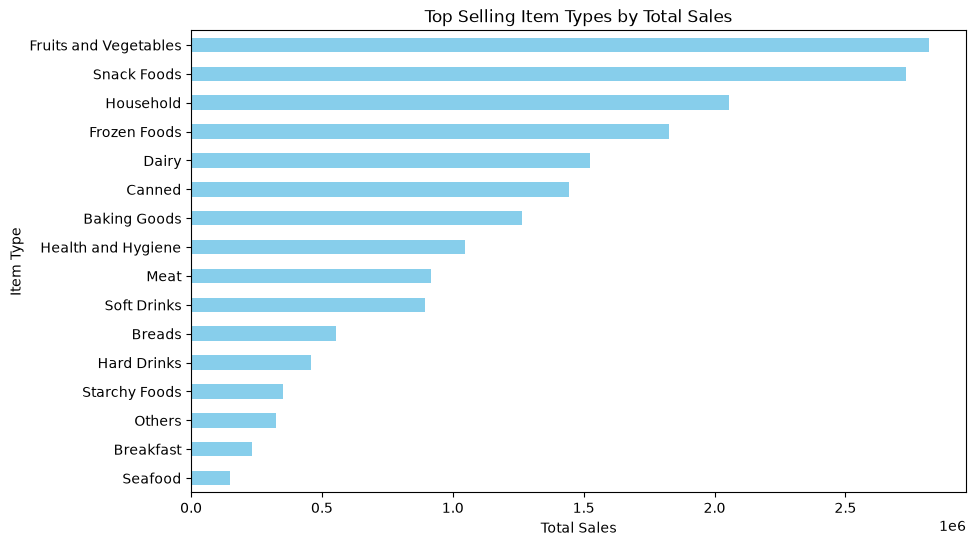

In [30]:
mlt.figure(figsize=(10,6))

ds.groupby('Item_Type')['Item_Outlet_Sales'].sum().sort_values().plot(
    kind='barh',
    color='skyblue'
)

mlt.title('Top Selling Item Types by Total Sales')
mlt.xlabel('Total Sales')
mlt.ylabel('Item Type')

mlt.show()

**Key Insights:

a). The graph shows the total sales generated by each product category.

b). It helps identify the best-selling item types and their contribution to overall sales.

c). Product categories with higher sales indicate greater customer demand.

## 2. Average Sales by Outlet Type
#### This bar chart compares the average sales across different outlet types.

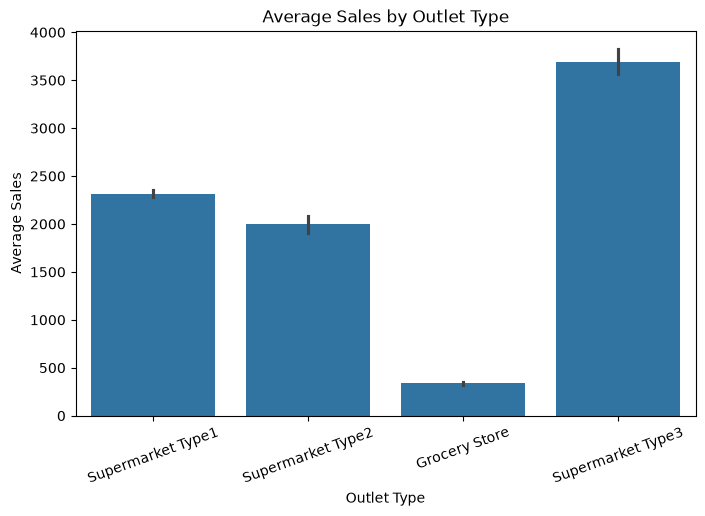

In [31]:
mlt.figure(figsize=(8,5))

sb.barplot(
    x='Outlet_Type',
    y='Item_Outlet_Sales',
    data=ds
)

mlt.title('Average Sales by Outlet Type')
mlt.xlabel('Outlet Type')
mlt.ylabel('Average Sales')

mlt.xticks(rotation=20)

mlt.show()

**Key Insights:

a). This graph compares the average sales across different outlet types.

b). It shows that supermarkets generally generate higher average sales than grocery stores.

c). The analysis indicates that outlet type significantly affects sales performance.

## 3. Sales Performance Across Different Outlet Locations
#### This box plot shows the distribution of sales across different outlet location types.

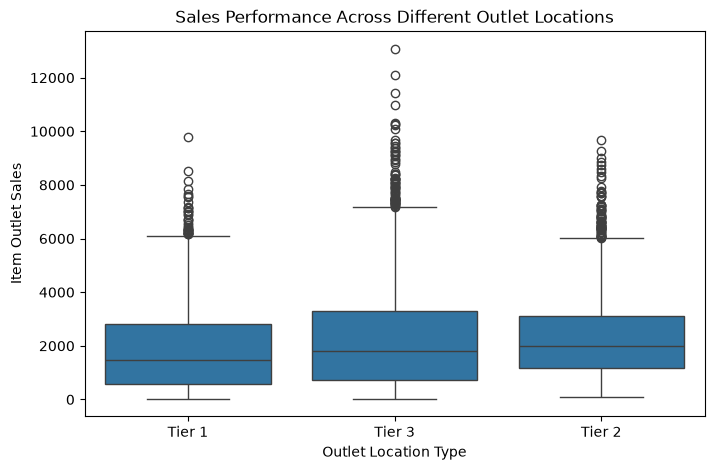

In [32]:
mlt.figure(figsize=(8,5))

sb.boxplot(
    x='Outlet_Location_Type',
    y='Item_Outlet_Sales',
    data=ds
)

mlt.title('Sales Performance Across Different Outlet Locations')
mlt.xlabel('Outlet Location Type')
mlt.ylabel('Item Outlet Sales')

mlt.show()

**Key Insights:

a). This graph illustrates the distribution of sales across different outlet locations.

b). It shows that sales vary according to outlet location.

c). Location plays an important role in influencing overall sales performance.

## 4. Distribution of Item Fat Content
#### This pie chart shows the proportion of Low Fat and Regular fat products.

In [33]:
ds['Item_Fat_Content'] = ds['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

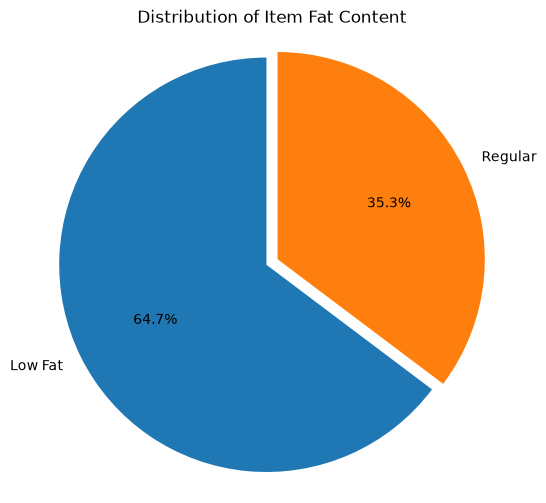

In [34]:
mlt.figure(figsize=(6,6))

mlt.pie(
    ds['Item_Fat_Content'].value_counts(),
    labels=ds['Item_Fat_Content'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.03, 0.03)
)

mlt.title("Distribution of Item Fat Content")
mlt.axis('equal')
mlt.show()

**Key Insights:

a). The pie chart represents the proportion of Low Fat and Regular products.

b). Low Fat products make up the majority of the dataset.

c). This provides an overview of the product composition based on fat content.

## 5. Impact of Outlet Establishment Year on Sales
#### This line chart shows how average sales vary with outlet establishment year.

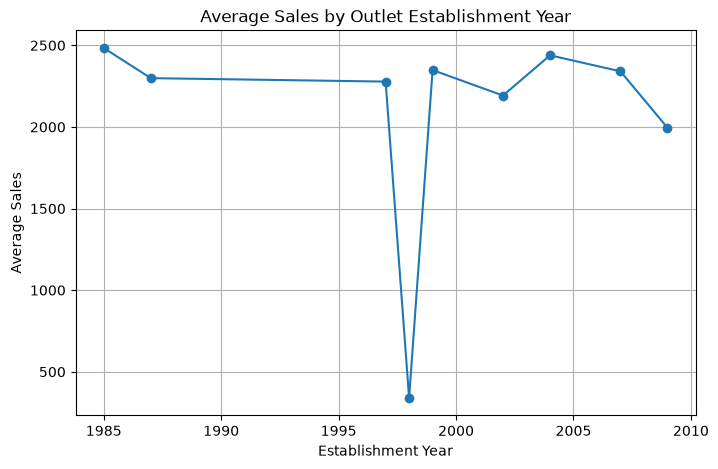

In [35]:
mlt.figure(figsize=(8,5))

ds.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].mean().plot(
    marker='o'
)

mlt.title('Average Sales by Outlet Establishment Year')
mlt.xlabel('Establishment Year')
mlt.ylabel('Average Sales')

mlt.grid(True)

mlt.show()

**Key Insights:

a). This graph compares average sales of outlets established in different years.

b). It helps determine whether older or newer outlets perform better.

c). The results indicate that establishment year has an impact on sales.

## 6. Average Item MRP by Item Type
#### This horizontal bar chart compares the average MRP of different product categories..

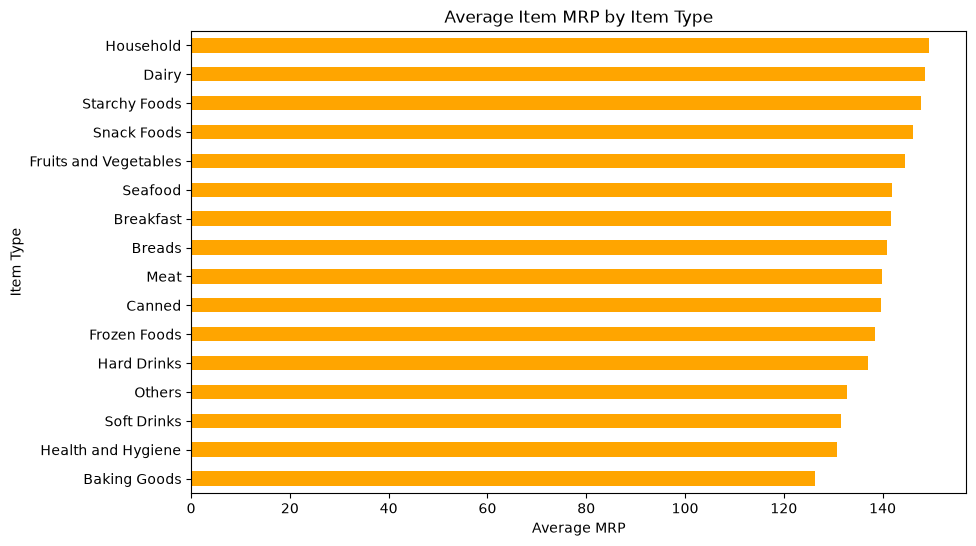

In [36]:
mlt.figure(figsize=(10,6))

ds.groupby('Item_Type')['Item_MRP'].mean().sort_values().plot(
    kind='barh',
    color='orange'
)

mlt.title('Average Item MRP by Item Type')
mlt.xlabel('Average MRP')
mlt.ylabel('Item Type')

mlt.show()

**Key Insights:

a). The graph compares the average Maximum Retail Price (MRP) across product categories.

b). Some product categories have higher average prices than others.

c). It provides insights into the pricing patterns of different items.

## 7. Distribution of Item MRP
#### This histogram displays the distribution of Maximum Retail Price (MRP) of products.

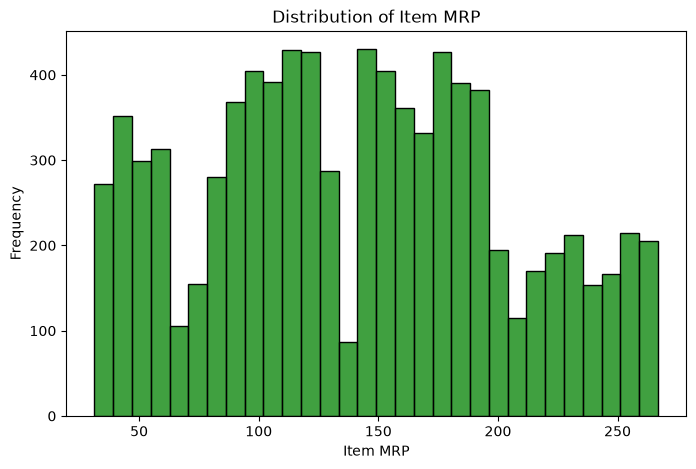

In [37]:
mlt.figure(figsize=(8,5))

sb.histplot(ds['Item_MRP'], bins=30, color='green')

mlt.title('Distribution of Item MRP')
mlt.xlabel('Item MRP')
mlt.ylabel('Frequency')

mlt.show()

**Key Insights:

a). The histogram shows the distribution of product prices in the dataset.

b). Most products are concentrated within a moderate price range.

c). Only a small number of products have very high MRP values.

## 8. Distribution of Item Visibility
#### This histogram illustrates how product visibility is distributed across the dataset.

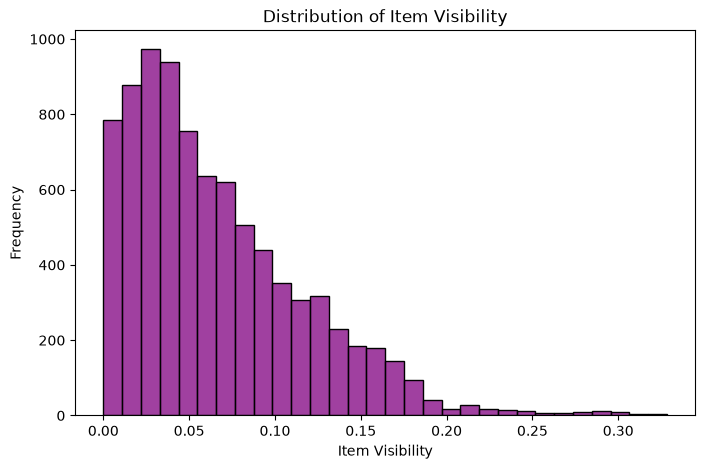

In [38]:
mlt.figure(figsize=(8,5))

sb.histplot(ds['Item_Visibility'], bins=30, color='purple')

mlt.title('Distribution of Item Visibility')
mlt.xlabel('Item Visibility')
mlt.ylabel('Frequency')

mlt.show()

**Key Insights:

a). This graph displays the distribution of item visibility values.

b). Most products have low to medium visibility.

c). Only a few products have exceptionally high visibility in stores.

## 9. Relationship Between Item MRP and Sales
#### This scatter plot shows the relationship between product price and outlet sales.

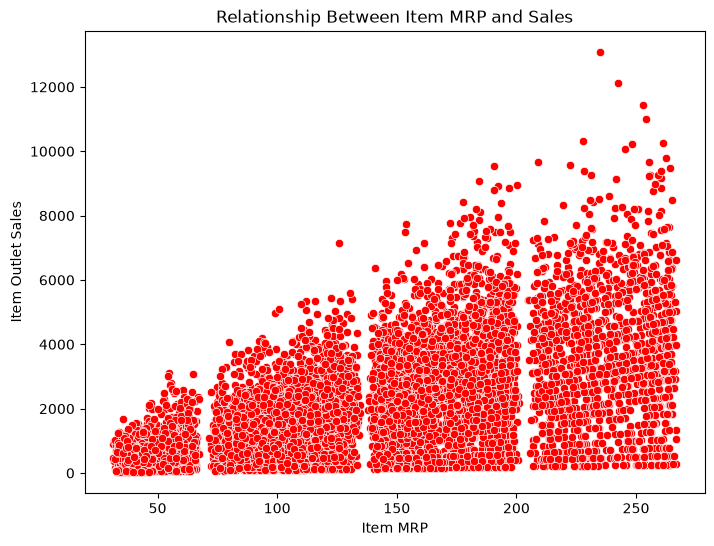

In [39]:
mlt.figure(figsize=(8,6))

sb.scatterplot(
    x='Item_MRP',
    y='Item_Outlet_Sales',
    data=ds,
    color='red'
)

mlt.title('Relationship Between Item MRP and Sales')
mlt.xlabel('Item MRP')
mlt.ylabel('Item Outlet Sales')

mlt.show()

**Key Insights:

a). The scatter plot shows the relationship between Item MRP and sales.

b). A positive trend can be observed between price and sales.

c). Higher-priced products generally generate higher sales revenue.

## 10. Correlation Heatmap of Numerical Features
#### This heatmap displays the correlation among all numerical variables in the dataset.

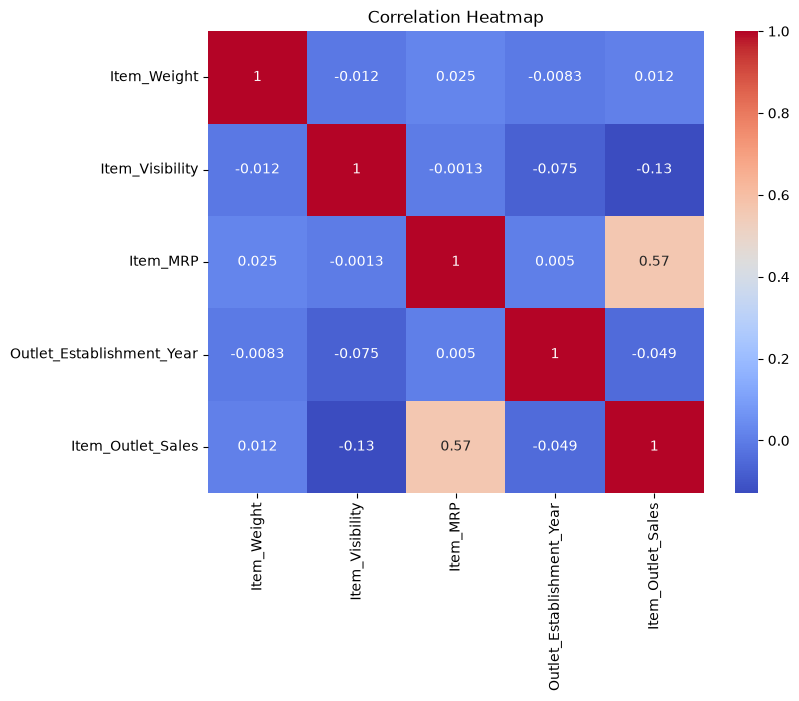

In [40]:
mlt.figure(figsize=(8,6))

sb.heatmap(
    ds.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

mlt.title('Correlation Heatmap')

mlt.show()

**Key Insights:

a). The heatmap shows the correlation among numerical variables.

b). It helps identify which features have stronger relationships with sales.

c). Item MRP shows a stronger positive correlation with sales than other numerical features.

## 11. Sales Distribution by Outlet Type
#### This violin plot shows the distribution and density of sales for each outlet type.

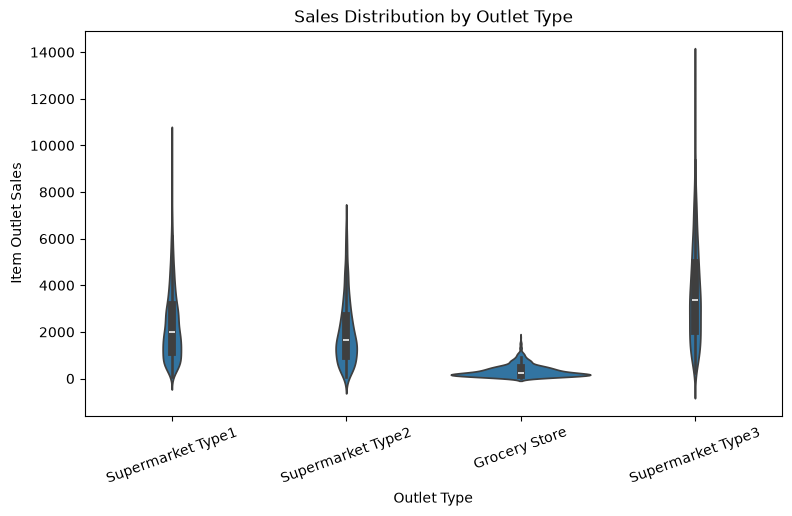

In [41]:
mlt.figure(figsize=(9,5))

sb.violinplot(
    x='Outlet_Type',
    y='Item_Outlet_Sales',
    data=ds
)

mlt.title('Sales Distribution by Outlet Type')
mlt.xlabel('Outlet Type')
mlt.ylabel('Item Outlet Sales')
mlt.xticks(rotation=20)

mlt.show()

**Key Insights:

a). This graph compares the distribution of sales across outlet types.

b). Some outlet types show higher median sales and greater variation.

c). It provides insights into the consistency of sales performance among outlets.

## 12. Product Category Distribution
#### This count plot displays the number of products available in each item category.

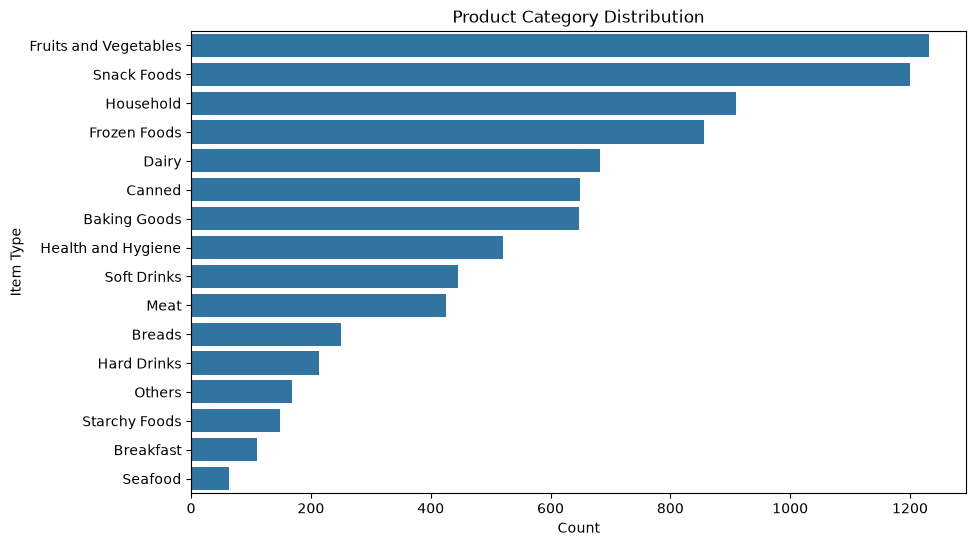

In [42]:
mlt.figure(figsize=(10,6))

sb.countplot(
    y='Item_Type',
    data=ds,
    order=ds['Item_Type'].value_counts().index
)

mlt.title('Product Category Distribution')
mlt.xlabel('Count')
mlt.ylabel('Item Type')

mlt.show()

**Key Insights:

a). The graph displays the number of products available in each category.

b). Some product categories contain more products than others.

c). It helps understand the overall composition of the dataset.

# Key Findings and Conclusions
Product attributes and outlet characteristics significantly influence sales, with Item MRP, outlet type, and product category being the key factors affecting Blinkit sales performance.

## Major Research Findings

## 1. Product Category
a) Different product categories contribute differently to overall sales.

b) Some categories generate higher sales due to greater customer demand.

c) Product category is an important factor affecting sales performance.

## 2. Outlet Type
a) Sales vary significantly across different outlet types.

b) Supermarkets generally record higher average sales than grocery stores.

c) Outlet type plays a key role in business performance.

## 3. Item MRP
a) Item MRP has a positive relationship with sales.

b) Higher-priced products tend to generate greater sales revenue.

c) Pricing is an important factor influencing customer purchases.

## 4. Outlet Location
a) Sales performance differs across outlet locations.

b) Location affects customer reach and product demand.

c) Well-located outlets generally achieve better sales performance.

## 5. Overall Conclusion
a) Both product attributes and outlet characteristics influence sales.

b) Data analysis helps identify key factors affecting business performance.

c) These insights can support better pricing, inventory, and marketing decisions.

## Policy Implications

### 🎯 Business Recommendations
1. **Product Management:** Increase the availability of high-selling product categories to meet customer demand.
2. **Pricing Strategy:** Adopt competitive pricing for products while maintaining profitability.
3. **Inventory Planning:** Maintain adequate stock levels for popular products to reduce stock shortages.
4. **Outlet Expansion:** Focus on expanding outlets in locations with higher sales potential.

### 🏪 Store Management
- **Customer Experience:** Improve product visibility and store layout to enhance customer satisfaction.
- **Outlet Performance:** Monitor outlet-wise sales regularly to identify high- and low-performing stores.
- **Marketing Strategies:** Design promotional campaigns based on customer preferences and product demand.

### 📋 Future Improvements
- **Sales Prediction:** Develop machine learning models to forecast future sales.
- **Customer Analysis:** Include customer demographics and purchasing behavior for deeper insights.
- **Business Intelligence:** Build interactive dashboards for real-time sales monitoring and decision-making.

## Summary and Next Steps

This analysis of the Blinkit Sales dataset provided valuable insights into the factors influencing product sales across different outlets. The findings highlight the importance of product characteristics, outlet features, and pricing in improving sales performance and supporting data-driven business decisions.

### 🔍 Key Takeaways
1. **Product category significantly impacts sales**, with some categories performing better than others.
2. **Outlet type and location influence overall sales**, indicating differences in customer demand.
3. **Item MRP has a positive relationship with sales**, making pricing an important business factor.
4. **Data visualization and EDA help identify sales trends**, enabling better inventory and marketing decisions.

### 📈 Future Scope
- **Sales Prediction:** Build machine learning models to forecast future sales.
- **Customer Analysis:** Include customer demographics and purchasing behavior for deeper insights.
- **Business Intelligence:** Develop interactive dashboards for real-time sales monitoring.
- **Advanced Analytics:** Apply clustering and recommendation techniques to improve business strategies.